In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch
import pickle
import tqdm
import itertools

from flab.empirics import ExptTrace, rcsetup
rcsetup(panel_color='parchment')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float64
RNG    = torch.Generator(device=DEVICE).manual_seed(42)
print(f'device={DEVICE}  dtype={DTYPE}')

def reseed(seed: int) -> None:
    global RNG
    RNG = torch.Generator(device=DEVICE).manual_seed(seed)

device=cuda  dtype=torch.float64


In [2]:
import torch.optim as optim


class Muon(optim.Optimizer):

    def __init__(self, params, lr: float = 0.01, ns_steps: int = 5):
        defaults = dict(lr=lr, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.compile
    def _polar(G: torch.Tensor) -> torch.Tensor:
        U, _, Vh = torch.linalg.svd(G, full_matrices=False)
        return U @ Vh

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                G = p.grad
                if G.ndim < 2:
                    update = G / (G.norm() + 1e-7)
                else:
                    update = Muon._polar(G)
                p.add_(update, alpha=-lr)

In [3]:
# == TARGET ===============================================================

N         = 128
PLANT_DIM = N // 4
SNR       = 4.0
MISALIGNMENT_EXPONENT = 0

reseed(0)

def make_target(n: int, r: int, snr: float) -> torch.Tensor:
    """Returns diag(singular values of  G/sqrt(n) + snr * U V^T)."""
    sv_signal = torch.zeros(n, dtype=DTYPE, device=DEVICE)
    sv_signal[:r] = snr
    G = torch.randn(n, n, dtype=DTYPE, device=DEVICE, generator=RNG)
    M = torch.diag(sv_signal) + G / np.sqrt(n)

    sv = 10 * torch.linalg.svdvals(M)
    sv[sv < 2.0] = 2.0
    print(sv)
    
    avg_gap = np.mean([(sv[i] / sv[r]).item() for i in range(r)])
    global MISALIGNMENT_EXPONENT
    MISALIGNMENT_EXPONENT = 2 * (1 - 1/avg_gap)
    
    return torch.diag(sv).to(dtype=DTYPE, device=DEVICE)

M_STAR = make_target(N, PLANT_DIM, SNR)
print(f'misalignment exponent = {MISALIGNMENT_EXPONENT:.3f}')

tensor([48.5851, 48.1225, 47.7495, 46.9986, 46.8186, 46.3676, 45.9664, 45.4084,
        44.9456, 44.8524, 44.6265, 44.0392, 43.8089, 43.3477, 42.8688, 42.3194,
        42.2176, 41.9807, 41.4020, 41.0963, 40.7470, 40.3396, 40.1215, 39.6795,
        39.4343, 38.7827, 38.6256, 38.0873, 37.7364, 36.4605, 36.2748, 35.5313,
        16.7487, 16.2714, 16.0698, 15.5345, 15.1585, 14.8887, 14.5052, 14.2642,
        14.0770, 13.9164, 13.5281, 13.4585, 13.3054, 13.0169, 12.7785, 12.3648,
        12.2593, 12.0348, 11.8837, 11.7805, 11.4435, 11.4070, 11.1033, 11.0135,
        10.9209, 10.6212, 10.5439, 10.3725, 10.1868, 10.0264,  9.9047,  9.6265,
         9.3870,  9.2552,  9.0499,  8.8024,  8.6688,  8.4961,  8.3624,  8.2030,
         7.9563,  7.8296,  7.6943,  7.6175,  7.4005,  7.1932,  6.9558,  6.8921,
         6.7409,  6.5806,  6.4652,  6.3637,  6.1534,  6.0712,  5.9448,  5.8526,
         5.6952,  5.5453,  5.4761,  5.3126,  5.1653,  4.9458,  4.8258,  4.6664,
         4.4522,  4.3304,  4.2442,  4.17

# Experiment

In [4]:
# == Alignment score ================================================================

def _block_align_score(O: np.ndarray, sv1: np.ndarray, sv2: np.ndarray,
                       rtol: float, atol: float) -> float:
    """For each of the three O matrices, we:
        1. Group the r = min(d,n) mode indices into degenerate blocks: adjacent
            pair (j-1, j) is merged when the SV gap in EITHER spectrum is too small
            to resolve as distinct.
        2. Score = (∑_block ||O[block,block]||_F²) / r  ∈ [0,1].
            Reduces to mean(diag(O)²) when all blocks are size-1 (no degeneracy).
            A block of size b scores b/r when O is perfectly block-unitary there.
    """    
    # sv gaps (relative and absolute)
    r1 = sv1[:-1] / np.maximum(sv1[1:], 1e-30)
    r2 = sv2[:-1] / np.maximum(sv2[1:], 1e-30)
    a1 = np.abs(sv1[:-1] - sv1[1:])
    a2 = np.abs(sv2[:-1] - sv2[1:])
    # a gap is counted only if both relative and absolute gaps exceed rtol and atol
    # otherwise the pair is part of a degenerate subspace
    sep = ((r1 > 1 + rtol) & (a1 > atol)) & ((r2 > 1 + rtol) & (a2 > atol))
    cuts = np.concatenate(([0], np.nonzero(sep)[0] + 1, [sv1.shape[0]]))

    total = 0.0
    for s, e in zip(cuts[:-1], cuts[1:]):
        sub = O[s:e, s:e]
        total += np.dot(sub.ravel(), sub.ravel())
    return total / O.shape[0]


def alignment_scores(W2: torch.Tensor, W1: torch.Tensor,
                     sv_target: np.ndarray, rtol: float = 0.2, atol: float = 1e-4) -> tuple:
    """Returns (align_left, align_right, align_in) ∈ [0,1].

    Target is assumed diagonal, so its left/right SVs are the standard basis.
    O_left[i,j]  = U[j,i]   (model left SVs vs target left SVs = e_i)
    O_right[i,j] = Vh[i,j]  (model right SVs vs target right SVs = e_i)
    O_in         = VhW2 @ VhW1T.T  (right SVs of W2 vs left SVs of W1)

    r = min(d,n) = rank of the factorization; only the top-r modes are used.
    Degenerate blocks for O_left/O_right use (sv_model[:r], sv_target[:r]).
    Degenerate blocks for O_in use (sv_W2, sv_W1).
    """
    r = min(W2.shape)

    with torch.no_grad():
        PQ = W2 @ W1
        U, sv_model_t, Vh = torch.linalg.svd(PQ, full_matrices=False)
        sv_model = sv_model_t.cpu().numpy()[:r]

        _, sv_W2_t, VhW2  = torch.linalg.svd(W2,    full_matrices=False)
        _, sv_W1_t, VhW1T = torch.linalg.svd(W1.mT, full_matrices=False)
        sv_W2 = sv_W2_t.cpu().numpy()
        sv_W1 = sv_W1_t.cpu().numpy()

    O_left  = U.cpu().numpy()[:r, :r]
    O_right = Vh.cpu().numpy()[:r, :r]
    O_in  = VhW2.cpu().numpy() @ VhW1T.cpu().numpy().T

    sv_tgt = sv_target[:r]
    al = _block_align_score(O_left,  sv_model, sv_tgt, rtol=rtol, atol=atol)
    ar = _block_align_score(O_right, sv_model, sv_tgt, rtol=rtol, atol=atol)
    ai = _block_align_score(O_in,  sv_W2, sv_W1, rtol=rtol, atol=atol**2)
    return al, ar, ai


In [5]:
# EXPERIMENT

@torch.compile
def _loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return 0.5 * (pred - target).pow(2).sum()

PARAM_RATIOS  = [0.25, 1.0, 4.0]
ALPHAS  = [1e-5, 1e-4, 1e-3]

align_left, align_right, align_in = ExptTrace.multi_init(3, ["iter", "param_ratio", "alpha"])
t_final = ExptTrace(["param_ratio", "alpha"])
reseed(64)
for ratio, alpha in tqdm.tqdm(list(itertools.product(PARAM_RATIOS, ALPHAS))):
    d = int(ratio * N)
    num_steps = 100
    if ratio == 0.25:
        if alpha == 1e-5:
            num_steps = 10_000
        if alpha == 1e-4:
            num_steps = 1000
    log_times = np.unique(np.concatenate(([0], np.geomspace(1, num_steps, 100, dtype=int))))
    
    lr = 0.2 * alpha
    sv_target = M_STAR.diagonal().cpu().numpy()

    init_scale = alpha / np.sqrt(max(N, d))
    W1 = torch.nn.Parameter(
        torch.randn(d, N, generator=RNG, dtype=DTYPE, device=DEVICE) * init_scale)
    W2 = torch.nn.Parameter(
        torch.randn(N, d, generator=RNG, dtype=DTYPE, device=DEVICE) * init_scale)

    opt = Muon([W1, W2], lr=lr)
    
    for t in range(num_steps):
        if t in log_times:
            al, ar, ai = alignment_scores(W2, W1, sv_target, rtol=0.08, atol=alpha)
            align_left[t, d/N, alpha] = al
            align_right[t, d/N, alpha] = ar
            align_in[t, d/N, alpha] = ai

        opt.zero_grad()
        loss = _loss(W2 @ W1, M_STAR)
        loss.backward()
        opt.step()
        
    with torch.no_grad():
        svals = torch.linalg.svdvals(W2 @ W1).detach().cpu().numpy()
    nsteps_remaining = (np.sqrt(max(sv_target)) - np.sqrt(svals[-1])) / lr
    t_final[d/N, alpha] = num_steps + nsteps_remaining

with open(f'fig3_traces.pkl', 'wb') as f:
    pickle.dump({
        'align_left': align_left.serialize(),
        'align_right': align_right.serialize(),
        'align_in': align_in.serialize(),
        't_final': t_final.serialize()
    }, f)

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [03:46<00:00, 25.13s/it] 


# Plotting

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


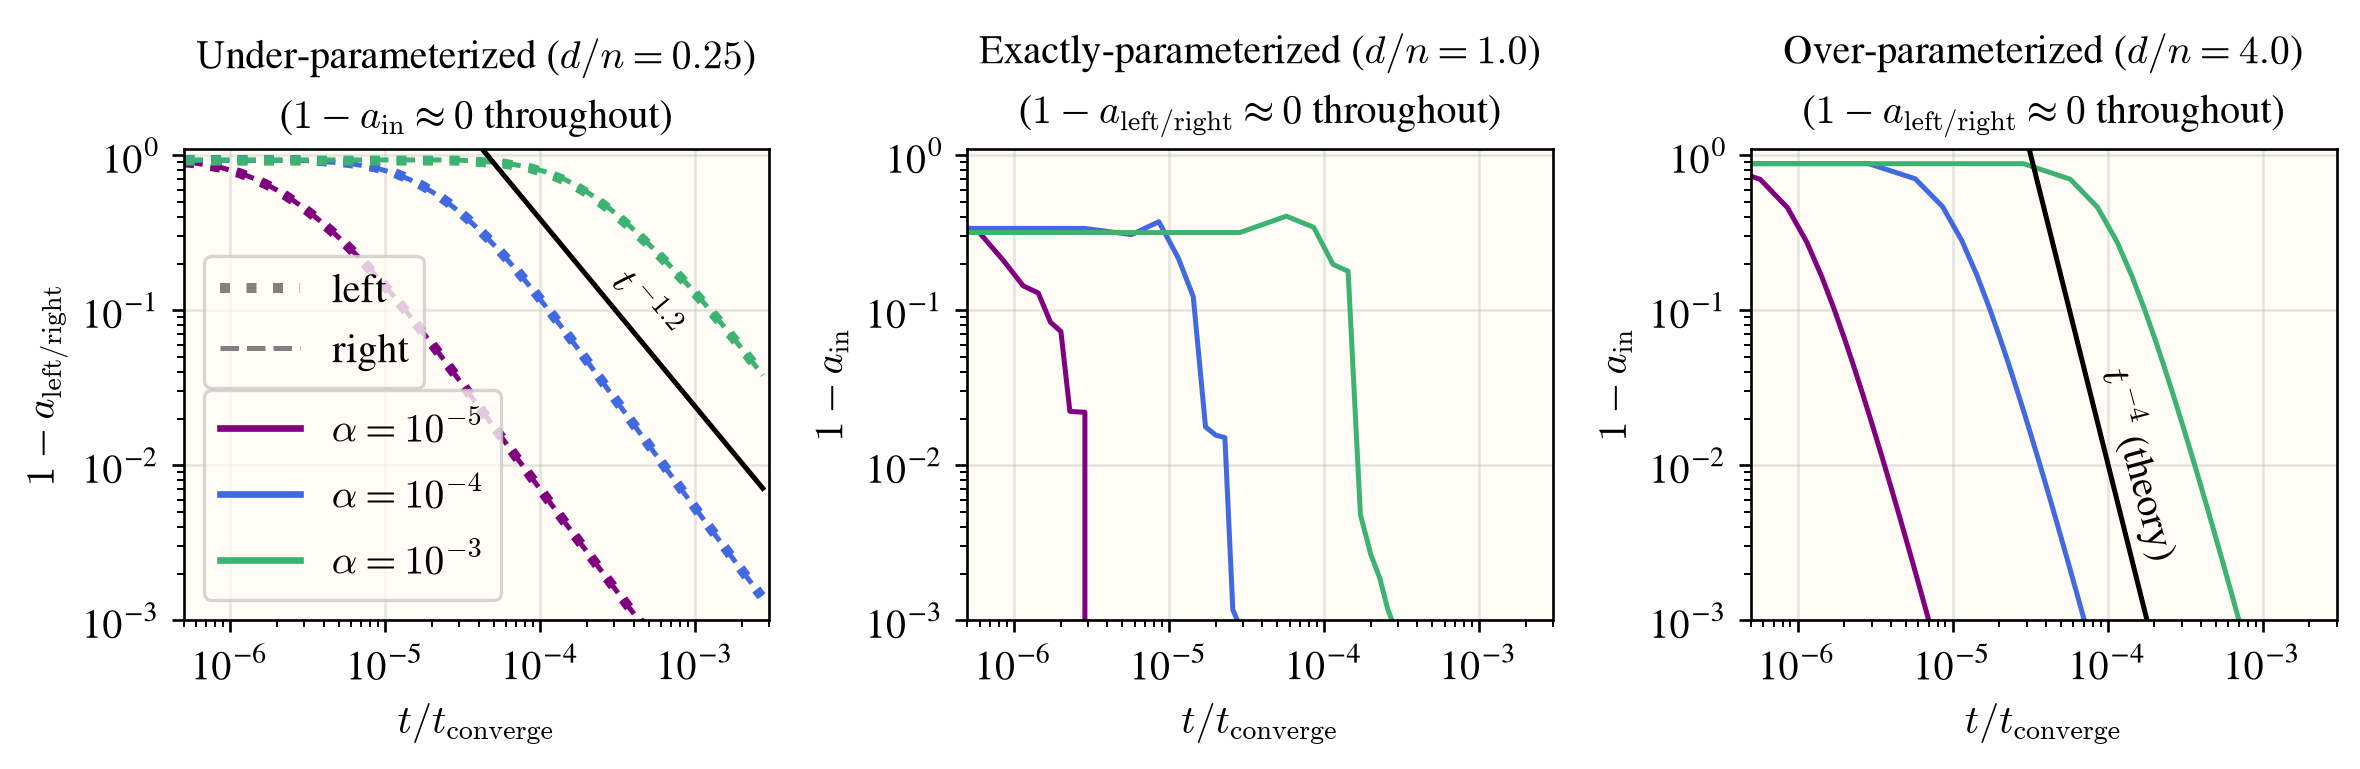

In [6]:
with open('fig3_traces.pkl', 'rb') as f:
    traces = pickle.load(f)
align_left = ExptTrace.deserialize(traces['align_left'])
align_right = ExptTrace.deserialize(traces['align_right'])
align_in = ExptTrace.deserialize(traces['align_in'])
t_final = ExptTrace.deserialize(traces['t_final'])

COLORS = ['purple', 'royalblue', 'mediumseagreen']
PARAM_RATIOS = [0.25, 1.0, 4.0]
ALPHAS       = [1e-5, 1e-4, 1e-3]

tt = np.array(align_in.get_axis("iter"))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

# --- panel 0: outer alignment, ratio=0.25 ---
ax = axes[0]
for alpha, color in zip(ALPHAS, COLORS):
    yl = align_left[:,  0.25, alpha].compressed()
    l_err = 1 - yl**2
    yr = align_right[:, 0.25, alpha].compressed()
    r_err = 1 - yr**2
    unmasked = np.where(~np.ma.getmaskarray(align_left[:,  0.25, alpha]))[0]
    tt_rel = tt[unmasked] / t_final[0.25, alpha]
    ax.plot(tt_rel, l_err, color=color, lw=3, ls=':')
    ax.plot(tt_rel, r_err, color=color, lw=1.5, ls='--')
ax.plot(tt_rel, (2.2e4*(1e-8+tt_rel))**(-MISALIGNMENT_EXPONENT), color='black', lw=1.5, ls='-')
ax.text(5e-4, 1e-1, f'$t^{{{-MISALIGNMENT_EXPONENT:.1f}}}$ ', fontsize=12, rotation=-50,
        ha='center', va='center')
# legend for line styles
handles = [Line2D([0], [0], color='grey', ls=':',  lw=3, label='left'),
           Line2D([0], [0], color='grey', ls='--', lw=1.5, label='right')]
style_legend = ax.legend(handles=handles, fontsize=12, loc='lower left',
                         bbox_to_anchor=(0, 0.45))
ax.add_artist(style_legend)
# legend for init scales (colors)
color_handles = [Line2D([0], [0], color=color, lw=2,
                        label=fr'$\alpha=10^{{{int(round(np.log10(alpha)))}}}$')
                 for alpha, color in zip(ALPHAS, COLORS)]
ax.legend(handles=color_handles, fontsize=12, loc='lower left')
ax.set_ylabel(f'$1 - a_{{\\text{{left/right}}}}$')
ax.set_title(f'Under-parameterized ($d/n = 0.25$)\n($1-a_{{\\text{{in}}}}\\approx 0$ throughout)', fontsize=12)

# --- panel 1: inner alignment, ratio=1.0 ---
ax = axes[1]
for alpha, color in zip(ALPHAS, COLORS):
    t_f = t_final[1.0, alpha]
    align = align_in[:, 1.0, alpha].compressed()
    err = 1 - align**2
    tt_rel = tt[:len(align)] / t_f
    ax.plot(tt_rel, err, color=color, lw=1.5)
ax.set_ylabel(f'$1 - a_{{\\text{{in}}}}$')
ax.set_title(f'Exactly-parameterized ($d/n = 1.0$)\n($1-a_{{\\text{{left/right}}}}\\approx 0$ throughout)', fontsize=12)

# --- panel 2: inner alignment, ratio=4.0 ---
ax = axes[2]
for alpha, color in zip(ALPHAS, COLORS):
    t_f = t_final[4.0, alpha]
    align = align_in[:, 4.0, alpha].compressed()
    err = 1 - align**2
    tt_rel = tt[:len(align)] / t_f
    ax.plot(tt_rel, err, color=color, lw=1.5)
ax.plot(tt_rel, (3.13e4*(1e-8+tt_rel))**(-4.), color='black', lw=1.5, ls='-')
ax.text(1.6e-4, 1e-2, r'$t^{-4}$ (theory)', fontsize=12, rotation=-75,
        ha='center', va='center')
ax.set_ylabel(f'$1 - a_{{\\text{{in}}}}$')
ax.set_title(f'Over-parameterized ($d/n = 4.0$)\n($1-a_{{\\text{{left/right}}}}\\approx 0$ throughout)', fontsize=12)

# --- global axis settings ---
for col, ratio in enumerate(PARAM_RATIOS):
    ax = axes[col]
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(f'$t/t_\\mathrm{{converge}}$')
    ax.set_ylim(1e-3, 1.1)
    ax.set_xlim(5e-7, 3e-3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('plots/fig3.pdf', bbox_inches='tight')
plt.show()
